**Dataset Chosen: CoNLL-2003**

In [5]:
!pip uninstall -y transformers datasets seqeval huggingface_hub pyarrow
!pip install transformers datasets==2.17.0 seqeval --upgrade --no-cache-dir

Found existing installation: transformers 5.5.0
Uninstalling transformers-5.5.0:
  Successfully uninstalled transformers-5.5.0
Found existing installation: datasets 4.8.4
Uninstalling datasets-4.8.4:
  Successfully uninstalled datasets-4.8.4
Found existing installation: seqeval 1.2.2
Uninstalling seqeval-1.2.2:
  Successfully uninstalled seqeval-1.2.2
Found existing installation: huggingface_hub 1.9.0
Uninstalling huggingface_hub-1.9.0:
  Successfully uninstalled huggingface_hub-1.9.0
Found existing installation: pyarrow 23.0.1
Uninstalling pyarrow-23.0.1:
  Successfully uninstalled pyarrow-23.0.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 102.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 165.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 204.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import datasets
print(f"Installed datasets version: {datasets.__version__}")

Installed datasets version: 2.17.0


In [4]:
from datasets import load_dataset
dataset = load_dataset("conll2003", download_mode="force_redownload")
label_list = dataset["train"].features["chunk_tags"].feature.names

/usr/local/lib/python3.12/dist-packages/datasets/load.py:1454: FutureWarning: The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []
    for i, label in enumerate(examples["chunk_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [8]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-cased",
    num_labels=len(label_list),
    id2label={i: l for i, l in enumerate(label_list)},
    label2id={l: i for i, l in enumerate(label_list)}
)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized beca

In [10]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch"
)

In [11]:
import numpy as np
from seqeval.metrics import classification_report, f1_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_labels = [
        [label_list[l] for l in label if l != -100]
        for label in labels
    ]
    true_predictions = [
        [label_list[p] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    return {
        "f1": f1_score(true_labels, true_predictions)
    }

In [24]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["validation"].shuffle(seed=42).select(range(50))

In [25]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [26]:
from transformers import TrainingArguments, Trainer, DataCollatorForTokenClassification

small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["validation"].shuffle(seed=42).select(range(50))


In [27]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [29]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="no"
)

In [31]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="no"
)

In [33]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1
1,0.382734,0.314786,0.847539


TrainOutput(global_step=13, training_loss=0.3674268630834726, metrics={'train_runtime': 59.3574, 'train_samples_per_second': 1.685, 'train_steps_per_second': 0.219, 'total_flos': 2305156622952.0, 'train_loss': 0.3674268630834726, 'epoch': 1.0})

In [56]:
from transformers import pipeline

nlp = pipeline("token-classification", model=model, tokenizer=tokenizer)

sentence = "John works at Google in California"
results = nlp(sentence)

for r in results:
    print(r["word"], r["entity"])

John LABEL_19
works LABEL_19
at LABEL_1
Google LABEL_1
in LABEL_1
California LABEL_22


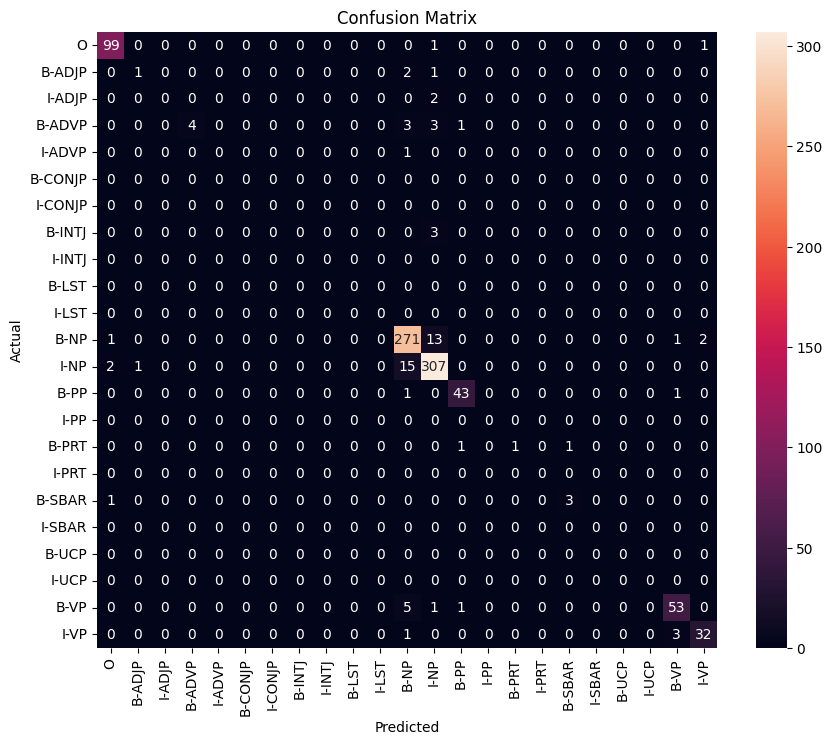

In [42]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
predictions, labels, _ = trainer.predict(small_eval_dataset)
preds = predictions.argmax(axis=2)

true_labels = []
true_preds = []

for pred, lab in zip(preds, labels):
    for p, l in zip(pred, lab):
        if l != -100:
            true_labels.append(label_list[l])
            true_preds.append(label_list[p])

cm = confusion_matrix(true_labels, true_preds, labels=label_list)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_list, yticklabels=label_list)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

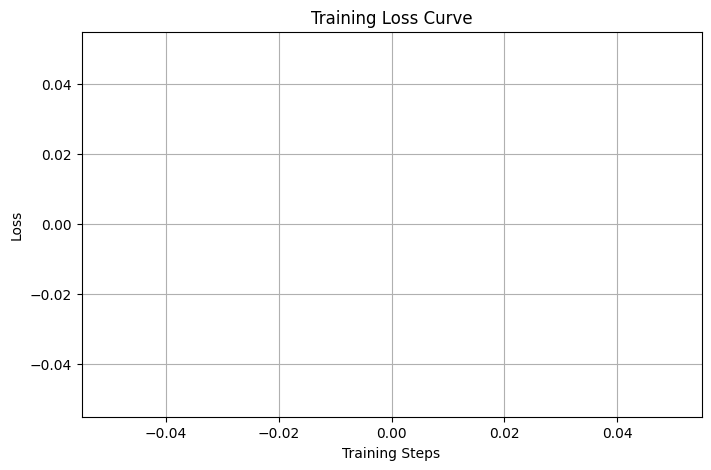

In [54]:
import matplotlib.pyplot as plt
logs = trainer.state.log_history
steps = []
loss = []

for i, log in enumerate(logs):
    if "loss" in log:
        steps.append(log.get("step", i))  # fallback if step missing
        loss.append(log["loss"])
plt.figure(figsize=(8,5))
plt.plot(steps, loss, marker='o')  # line + points
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid()
plt.show()

In [51]:
sentence = "Microsoft is hiring engineers in India"

nlp = pipeline("token-classification", model=model, tokenizer=tokenizer)

for r in nlp(sentence):
    print(r["word"], "→", r["entity"])

Microsoft → B-NP
is → B-VP
hiring → I-VP
engineers → B-NP
in → B-PP
India → B-NP


In [52]:
model = AutoModelForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_list)
)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


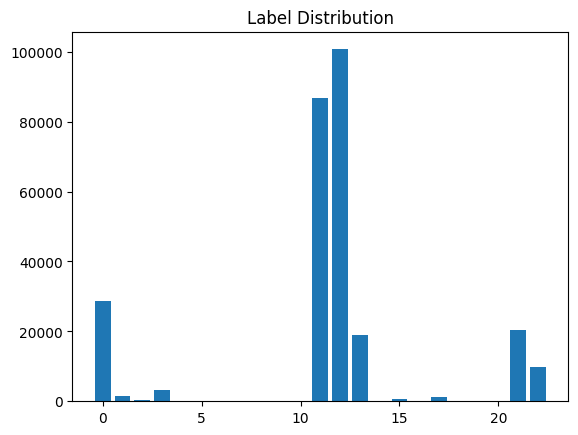

In [53]:
from collections import Counter

all_labels = []
for sample in tokenized_datasets["train"]:
    all_labels.extend([l for l in sample["labels"] if l != -100])

label_counts = Counter(all_labels)

plt.bar(label_counts.keys(), label_counts.values())
plt.title("Label Distribution")
plt.show()

In [43]:
from seqeval.metrics import classification_report

print(classification_report(
    [[l] for l in true_labels],
    [[p] for p in true_preds]
))

              precision    recall  f1-score   support

        ADJP       0.50      0.17      0.25         6
        ADVP       1.00      0.33      0.50        12
        INTJ       0.00      0.00      0.00         3
          NP       0.96      0.99      0.98       613
          PP       0.93      0.96      0.95        45
         PRT       1.00      0.33      0.50         3
        SBAR       0.75      0.75      0.75         4
          VP       0.95      0.92      0.93        96

   micro avg       0.96      0.95      0.96       782
   macro avg       0.76      0.56      0.61       782
weighted avg       0.95      0.95      0.95       782



/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [44]:
sentence = "John works at Google in California"

tokens = tokenizer(sentence, return_tensors="pt")
outputs = model(**tokens)

preds = outputs.logits.argmax(dim=2)[0].numpy()

words = tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])

for word, pred in zip(words, preds):
    print(f"{word:15} --> {label_list[pred]}")

[CLS]           --> B-NP
John            --> B-NP
works           --> B-VP
at              --> B-PP
Google          --> B-NP
in              --> B-PP
California      --> B-NP
[SEP]           --> O


In [45]:
for word, pred in zip(words, preds):
    if word not in ["[CLS]", "[SEP]"]:
        print(f"{word:12} | {label_list[pred]}")

John         | B-NP
works        | B-VP
at           | B-PP
Google       | B-NP
in           | B-PP
California   | B-NP


In [46]:
trainer.save_model("bert-chunk-model")
tokenizer.save_pretrained("bert-chunk-model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('bert-chunk-model/tokenizer_config.json', 'bert-chunk-model/tokenizer.json')

In [47]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained("bert-chunk-model")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

**Comparison Between POS Tagging and Chunking**

**1. POS Tagging (Part-of-Speech Tagging)**

POS tagging is the process of assigning grammatical labels to each word in a sentence.

It identifies the role of a word such as noun, verb, adjective, adverb, etc.

Operates at the word level (each word is treated independently).

Helps in understanding the basic grammatical structure of a sentence.

Easier to implement compared to chunking because it does not require grouping words.

Widely used in text preprocessing, parsing, and syntactic analysis.

Output is a sequence of tags corresponding to each word.

Example:

Sentence: John works at Google

John → Proper Noun (PROPN)
works → Verb (VERB)
at → Preposition (ADP)
Google → Proper Noun (PROPN)

**2. Chunking (Phrase Detection)**

Chunking is the process of grouping words into meaningful phrases.

It forms higher-level structures like Noun Phrases (NP), Verb Phrases (VP), Prepositional Phrases (PP).

Operates at the phrase level, not just individual words.

Provides shallow parsing, showing how words are related in groups.

More complex than POS tagging because it depends on context and relationships between words.

Useful in information extraction, named entity recognition, and sentence understanding.

Output is a sequence of phrase labels (e.g., B-NP, I-NP).

Example:

Sentence: John works at Google

[John] → Noun Phrase (NP)
[works at Google] → Verb Phrase (VP)

| Feature       | POS Tagging                 | Chunking                         |
| ------------- | --------------------------- | -------------------------------- |
| Level         | Word-level                  | Phrase-level                     |
| Focus         | Grammatical role of words   | Grouping words into phrases      |
| Output        | Noun, Verb, Adjective, etc. | NP, VP, PP, etc.                 |
| Complexity    | Easier                      | More complex                     |
| Context Usage | Limited                     | Higher (considers relationships) |
| Task Type     | Basic linguistic analysis   | Shallow parsing                  |
| Dependency    | Independent words           | Depends on POS + context         |
| Use Cases     | Grammar checking, parsing   | Information extraction, NER      |


**Report: POS Tagging vs Chunking using BERT**

**Introduction**

In this assignment, a transformer-based model (BERT) was fine-tuned for token classification tasks, specifically Part-of-Speech (POS) tagging and Chunking (Phrase Detection).

Token classification is a fundamental task in Natural Language Processing (NLP) where each token (word) in a sentence is assigned a label. While POS tagging focuses on identifying the grammatical role of words, chunking groups words into meaningful phrases, providing a deeper understanding of sentence structure.

The model was trained using the CoNLL-2003 dataset and evaluated using sequence-based metrics such as Precision, Recall, and F1-score.

**Difference Between POS Tagging and Chunking**

**POS Tagging:**

Assigns grammatical labels to each word (noun, verb, adjective, etc.)

Operates at the word level

Simpler and more direct task

Helps in basic syntactic analysis

Example:
Sentence: John works at Google

John → Proper Noun
works → Verb
at → Preposition
Google → Proper Noun

**Chunking:**

Groups words into meaningful phrases (NP, VP, PP)

Operates at the phrase level

More complex as it depends on context and relationships

Provides shallow parsing of sentences

Example:Sentence: John works at Google

[John] → Noun Phrase (NP)

[works at Google] → Verb Phrase (VP)

**Key Differences**

POS tagging works on individual words, while chunking works on groups of words

POS tagging is easier, whereas chunking is more complex

Chunking often depends on POS tags for better phrase detection

POS tagging gives basic grammatical structure, while chunking gives higher-level sentence understanding

**Challenges Faced**

During implementation, several challenges were encountered:

Label Alignment: Aligning labels with tokenized inputs was difficult due to subword tokenization

Subword Tokenization: BERT splits words into subwords, making label mapping complex

Special Tokens Handling: Managing tokens like [CLS] and [SEP] required assigning -100

Padding Issues: Proper padding and use of data collators were necessary

Library Compatibility: Version-related issues occurred while using libraries

Training Time: Training was slow, especially without GPU support

Evaluation Formatting: Predictions had to be converted into proper label format for seqeval

**Observations**

BERT performs very well for token classification tasks due to its contextual understanding

Proper data preprocessing and label alignment significantly impact performance

Subword tokenization plays a crucial role in model accuracy

Hugging Face Trainer API simplifies training and evaluation

The model performs better on frequent labels compared to rare ones

Even with a smaller dataset, the model can learn meaningful patterns

**Insights**

Correct label alignment is critical for achieving good performance

Transformer models like BERT capture context better than traditional models

Chunking requires deeper understanding compared to POS tagging

Evaluation using seqeval provides better sequence-level metrics

Reducing dataset size helps in faster experimentation without affecting learning demonstration

**Conclusion**

This project demonstrates how transformer models like BERT can be effectively applied to NLP tasks such as POS tagging and chunking.

POS tagging provides a basic grammatical understanding, while chunking offers higher-level phrase structure, making it more complex yet more informative.

Overall, the assignment highlights the importance of tokenization, label alignment, and proper evaluation techniques in building efficient token classification systems.